In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, TypeVar

InputType = TypeVar('InputType') # Type for input data of function
ReturnType = TypeVar('ReturnType') # Type for output of function

# ========== FEED-FORWARDING - FORWARD PROPAGATION ==========

# Define sigmoid function
def sigmoid(a: InputType) -> ReturnType:
    Z1 = 1 / (1 + np.exp(-a))
    return Z1

# Define softmax function
# def softmax(a: np.ndarray) -> ReturnType:
#     expA = np.exp(a)
#     A = expA / expA.sum(axis=1, keepdims=True)
#     return A

def softmax(a: InputType):
    a -= np.max(a, axis=1, keepdims=True)  # for numerical stability
    expA = np.exp(a)
    A = expA / expA.sum(axis=1, keepdims=True)
    return A

# Define forward propagation - 
def forward_pass(X, W1, b1, W2, b2, 
                 sigmoid_func: Callable[[InputType], ReturnType], 
                 softmax_func: Callable[[InputType], ReturnType]) -> ReturnType:
    Z1 = X.dot(W1) + b1
    A1 = sigmoid_func(Z1)
    Z2 = A1.dot(W2) + b2
    A2 = softmax_func(Z2)
    return A2, A1

# Determine the classification rate - Number of correct classifications / Total number of classifications
def classification_rate(T, Y_pred):
    # P -> predicted probabilities, Y -> true labels (targets)
    predicted_labels = np.argmax(Y_pred, axis=1)
    true_labels = np.argmax(T, axis=1)
    return np.mean(predicted_labels == true_labels)
    
# =========== DERIVATIVES - BACKPROPAGATION ==========

# Define the derivative (W2) function -> derivative of W2 with respect to cost
def derivative_W2(Z, T, Y):
    # m = T.shape[0]
    return Z.T.dot(T - Y)

# Define the derivative (b2) function
def derivative_b2(T, Y):
    return np.sum(T - Y, axis=0)

# Define the derivative (W1) function - d (delta) -> derivative of W1 with respect to cost
def derivative_W1(X, Z, T, Y, W2):
    """
    Computes the derivative of the cost function with respect to the weights W1.

    Parameters:
    X (np.ndarray): Input data matrix where each row is a data point.
    Z (np.ndarray): Activation values from the hidden layer.
    T (np.ndarray): Target output matrix (one-hot encoded).
    Y (np.ndarray): Predicted output matrix from the network.
    W2 (np.ndarray): Weights matrix for the second layer.

    Returns:
    np.ndarray: The gradient of the cost function with respect to W1.
    """
    dZ = (T - Y).dot(W2.T) * Z * (1 - Z)
    return X.T.dot(dZ)

# Define the cross-entropy loss function
def derivative_b1(T, Y, W2, Z):
    # dZ = np.outer(T - Y, W2.T) * (1 - Z * Z)
    dZ = (T - Y).dot(W2.T) * Z * (1 - Z)
    return np.sum(dZ, axis=0)

# =========== For Binary Classification (Sigmoid Output) ==========

# Cross-Entropy Loss (to minimize)
def binary_cross_entropy_loss(T, Y):
    epsilon = 1e-9 # epsilon prevents log(0)
    return -np.sum(T * np.log(Y + epsilon) + (1 - T) * np.log(1 - Y + epsilon))

# Log Likelihood (to maximize)
def binary_log_likelihood(T, Y):
    # Same as negative of binary cross-entropy
    epsilon = 1e-9
    return np.sum(T * np.log(Y + epsilon) + (1 - T) * np.log(1 - Y + epsilon))

# =========== For Multi-Class Classification (Softmax Output) ==========

# Cross-Entropy Loss (to minimize)
def multi_class_cross_entropy_loss(T, Y):
    epsilon = 1e-9
    return -np.sum(T * np.log(Y + epsilon))

# Log Likelihood (to maximize)
def multi_class_log_likelihood(T, Y):
    # Same as negative of multi-class cross-entropy
    epsilon = 1e-9
    return np.sum(T * np.log(Y + epsilon))

# Gradient Descent Optimizer (minimize cross-entropy loss)
def gradient_descent(
        X, T, W1, b1, W2, b2, 
        initial_lr, epochs, 
        sigmoid_func, softmax_func, 
        lr_scheduler=None, decay_rate=0.0
    ):
    costs = []
    acc_rate = []

    for epoch in range(epochs):

        lr = lr_scheduler(initial_lr, decay_rate, epoch) if lr_scheduler else initial_lr

        # Forward pass
        Y_pred, Z_hidden = forward_pass(X, W1, b1, W2, b2, sigmoid_func, softmax_func)

        # Cross-entropy loss
        cost_val = binary_cross_entropy_loss(T, Y_pred)

        # Gradients (softmax + cross-entropy simplified)
        dZ2 = Y_pred - T
        dW2 = Z_hidden.T @ dZ2
        db2 = np.sum(dZ2, axis=0)

        dZ1 = (dZ2 @ W2.T) * Z_hidden * (1 - Z_hidden)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0)

        # Gradient Descent updates
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

        costs.append(cost_val)
        acc_rate.append(classification_rate(T, Y_pred))

        if epoch % 200 == 0 or epoch == epochs - 1:
            acc = classification_rate(T, Y_pred)
            print(f"Epoch: {epoch + 1}        Lost: {cost_val:.5f}      LR: {lr:.5f}      Classification Rate (Accuracy): {acc * 100:.2f} \n")

    # Plot the cost function over epochs
    plt.plot(costs)
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.title("Gradient Descent: Minimizing Cross-Entropy Loss")
    plt.grid(True)
    plt.show()

    # Plot the train accuracy over epochs
    plt.plot(acc_rate)
    plt.xlabel("Epoch")
    plt.ylabel("Classification Rate (Accuracy)")
    plt.title("Gradient Descent: Minimizing Cross-Entropy Loss")
    plt.grid(True)
    plt.show()

    return W1, b1, W2, b2, costs

# Stochastic Gradient Descent Optimizer (minimize cross-entropy loss)
def stochastic_gradient_descent(
        X, T, W1, b1, W2, b2, 
        initial_lr, epochs, 
        batch_size, sigmoid_func, softmax_func, 
        lr_scheduler=None, decay_rate=0.0
    ):
    
    m = X.shape[0]
    costs = []
    acc_rate = []

    for epoch in range(epochs):
        # Apply learning rate scheduler if provided
        lr = lr_scheduler(initial_lr, decay_rate, epoch) if lr_scheduler else initial_lr

        # Shuffle dataset
        indices = np.arange(m)
        np.random.shuffle(indices)
        X_shuffled = X[indices]
        T_shuffled = T[indices]

        # Mini-batch processing
        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            T_batch = T_shuffled[i:i+batch_size]

            # Forward pass
            Y_pred_batch, Z_hidden = forward_pass(X_batch, W1, b1, W2, b2, sigmoid_func, softmax_func)

            # Compute gradients
            # dW2 = derivative_W2(Z_hidden, T_batch, Y_pred_batch)
            # db2 = derivative_b2(T_batch, Y_pred_batch)
            # dW1 = derivative_W1(X_batch, Z_hidden, T_batch, Y_pred_batch, W2)
            # db1 = derivative_b1(T_batch, Y_pred_batch, W2, Z_hidden)

            dZ2 = Y_pred_batch - T_batch                         # Shape: (batch_size, classes)
            dW2 = Z_hidden.T.dot(dZ2) / batch_size         # Shape: (hidden_units, classes)
            db2 = np.mean(dZ2, axis=0)

            dZ1 = dZ2.dot(W2.T) * Z_hidden * (1 - Z_hidden)  # For sigmoid; change if using ReLU
            dW1 = X_batch.T.dot(dZ1) / batch_size
            db1 = np.mean(dZ1, axis=0)

            # Update parameters
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

        # Evaluate loss and accuracy on the full dataset after epoch
        Y_all, _ = forward_pass(X, W1, b1, W2, b2, sigmoid_func, softmax_func)
        total_loss = multi_class_cross_entropy_loss(T, Y_all)
        acc = classification_rate(T, Y_all)
        costs.append(total_loss)
        acc_rate.append(acc)

        # Logging
        if epoch % 200 == 0 or epoch == epochs - 1:
            print(f"Epoch: {epoch:4d}    Loss: {total_loss:.5f}    LR: {lr:.5f}    Accuracy: {acc * 100:.2f}%\n")

    # Plot loss
    plt.plot(costs)
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.title("SGD Training Loss Over Epochs")
    plt.grid(True)
    plt.show()

    # Plot accuracy
    plt.plot(acc_rate)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("SGD Accuracy Over Epochs")
    plt.grid(True)
    plt.show()

    return W1, b1, W2, b2, costs

# Gradient Ascent Optimizer (maximize log-likelihood)
def gradient_ascent(
        X, T, W1, b1, W2, b2, 
        initial_lr, epochs, 
        sigmoid_func, softmax_func, 
        lr_scheduler=None, decay_rate=0.0
    ):
    
    costs = []
    acc_rate = []

    for epoch in range(epochs):

        lr = lr_scheduler(initial_lr, decay_rate, epoch) if lr_scheduler else initial_lr

        # Forward pass
        Y_pred, Z_hidden = forward_pass(X, W1, b1, W2, b2, sigmoid_func, softmax_func)

        # Log-likelihood
        log_likelihood = multi_class_log_likelihood(T, Y_pred)  # Adds epsilon to avoid log(0)

        # Gradients using simplified derivation for softmax + log-likelihood
        dZ2 = T - Y_pred
        dW2 = Z_hidden.T @ dZ2
        db2 = np.sum(dZ2, axis=0)

        dZ1 = (dZ2 @ W2.T) * Z_hidden * (1 - Z_hidden)  # sigmoid derivative
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0)

        # Gradient Ascent updates
        W1 += lr * dW1
        b1 += lr * db1
        W2 += lr * dW2
        b2 += lr * db2

        costs.append(-log_likelihood)
        acc_rate.append(classification_rate(T, Y_pred))

        if epoch % 200 == 0 or epoch == epochs - 1:
            acc = classification_rate(T, Y_pred)
            print(f"Epoch: {epoch + 1}        Log-Likelihood: {log_likelihood:.5f}      LR: {lr:.5f}      Classification Rate (Accuracy): {acc * 100:.2f} \n")

    # Plot the cost function over epochs
    plt.plot(costs)
    plt.xlabel("Iteration")
    plt.ylabel("Negative Log-Likelihood")
    plt.title("Gradient Ascent: Maximizing Log Likelihood")
    plt.grid(True)
    plt.show()

    # Plot the train accuracy over epochs
    plt.plot(acc_rate)
    plt.xlabel("Iteration")
    plt.ylabel("Classification Rate (Accuracy)")
    plt.title("Gradient Ascent: Maximizing Log Likelihood")
    plt.grid(True)
    plt.show()

    return W1, b1, W2, b2, costs

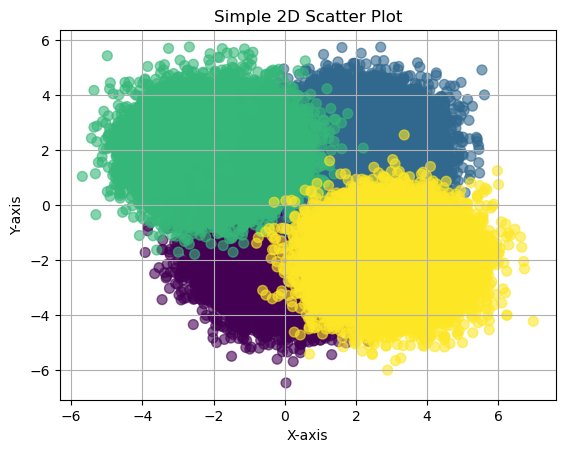

Epoch:    0    Loss: 35410.69537    LR: 0.10000    Accuracy: 91.77%

Epoch:  200    Loss: 13349.45280    LR: 0.08187    Accuracy: 93.66%

Epoch:  400    Loss: 13267.35906    LR: 0.06703    Accuracy: 93.68%

Epoch:  600    Loss: 13229.63080    LR: 0.05488    Accuracy: 93.68%

Epoch:  800    Loss: 13221.44301    LR: 0.04493    Accuracy: 93.70%

Epoch: 1000    Loss: 13214.91563    LR: 0.03679    Accuracy: 93.69%

Epoch: 1200    Loss: 13205.13162    LR: 0.03012    Accuracy: 93.69%

Epoch: 1400    Loss: 13193.94401    LR: 0.02466    Accuracy: 93.70%

Epoch: 1600    Loss: 13189.78409    LR: 0.02019    Accuracy: 93.70%

Epoch: 1800    Loss: 13193.21715    LR: 0.01653    Accuracy: 93.69%

Epoch: 2000    Loss: 13195.89288    LR: 0.01353    Accuracy: 93.70%

Epoch: 2200    Loss: 13187.90381    LR: 0.01108    Accuracy: 93.70%

Epoch: 2400    Loss: 13185.50291    LR: 0.00907    Accuracy: 93.69%

Epoch: 2600    Loss: 13182.41451    LR: 0.00743    Accuracy: 93.69%

Epoch: 2800    Loss: 13181.82223  

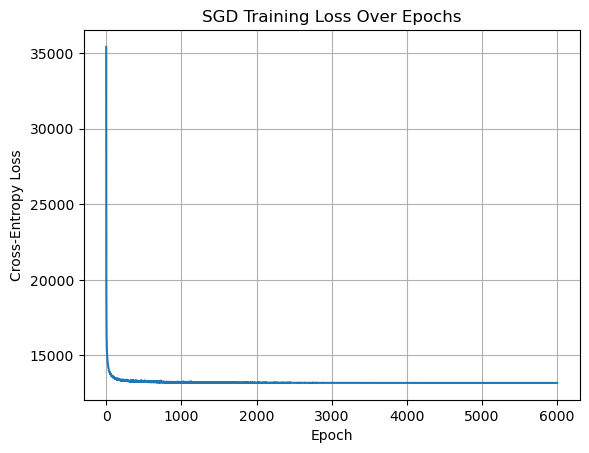

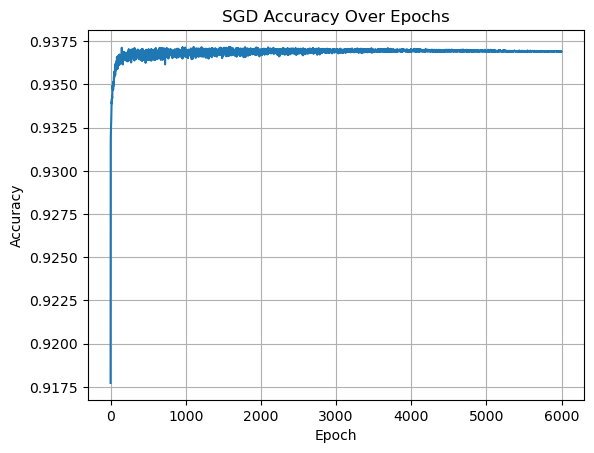

Final Weights (W1): [[-0.10130405  0.4923048   0.72704665]
 [ 0.94469905 -0.22503267  0.1242838 ]]
Final Biases (b1): [ 0.06998818 -0.17043121 -0.78395903]
Final Weights (W2): [[-7.90074422  7.7239564   8.4573862  -8.89225217]
 [ 2.04027929 -0.33806748 -9.25186964  8.96076946]
 [-6.10317586  9.07395127 -9.13994047  7.49797822]]
Final Biases (b2): [ 8.11841492 -5.60820344  3.81301417 -3.76832031]
Final Accuracy: 93.69%


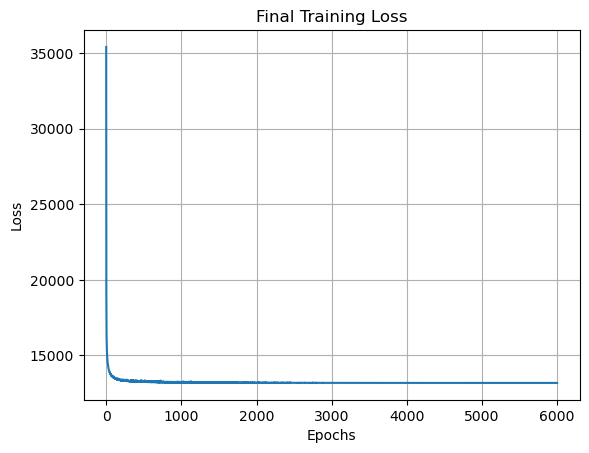

In [2]:
# Main function
from sklearn.model_selection import train_test_split


def main():

    Nclass = 20_000 # Number of data points
    np.random.seed(42) # Set seed for reproducibility

    # Create the data
    D = 2 # Dimensionality of input
    M = 3 # Hidden layer size
    K = 4 # Number of classes

    # Generate synthetic data
    # Generate 3 Gaussian blobs - These represent 3 classes with different means and variances
    X1 = np.random.randn(Nclass, 2) + np.array([0, -2])
    X2 = np.random.randn(Nclass, 2) + np.array([2, 2])
    X3 = np.random.randn(Nclass, 2) + np.array([-2, 2])
    X4 = np.random.randn(Nclass, 2) + np.array([3, -2])

    # Stack the data vertically
    X = np.vstack([X1, X2, X3, X4])
    # Create labels: 0 for X1, 1 for X2, 2 for X3, 3 for X4
    Y = np.array([0]*Nclass + [1]*Nclass + [2]*Nclass + [3]*Nclass)

    # Sanity check
    assert len(X) == len(Y), "Mismatch between data and labels!"

    # Turn Y (targets) into an indicator (one-hot) matrix for training
    T = np.zeros((len(Y), K))
    for i in range(len(Y)):
        T[i, Y[i]] = 1

    # Plot the scatter
    plt.scatter(X[:, 0], X[:, 1], c=Y, s=50, alpha=0.6, cmap='viridis')
    plt.title("Simple 2D Scatter Plot")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.grid(True)
    plt.show()

    # Randomly initialize weights and biases - Uses Xavier/Glorot Initialization (for sigmoid)
    W1 = np.random.randn(D, M) / np.sqrt(D)
    b1 = np.random.randn(M)
    W2 = np.random.randn(M, K) / np.sqrt(M)
    b2 = np.random.randn(K)

    # Define hyperparameters
    # l2_reg = 0.01
    batch_size = 200
    initial_lr = 0.1
    decay_rate = 0.001  # Controls how fast learning rate decays
    epochs = 6_000

    def lr_scheduler(initial_lr, decay_rate, epoch):
        return initial_lr * np.exp(-decay_rate * epoch)

    # Training loop - Gradient Descent
    # W1, b1, W2, b2, costs = gradient_descent(
    #     X, T, W1, b1, W2, b2, 
    #     initial_lr, epochs,
    #     sigmoid, softmax,
    #     lr_scheduler=lr_scheduler,
    #     decay_rate=decay_rate
    # )

    # Training loop - SGD (Stochastic Gradient Descent)
    W1, b1, W2, b2, costs = stochastic_gradient_descent(
        X, T, W1, b1, W2, b2,
        initial_lr, epochs,
        batch_size, sigmoid, softmax,
        lr_scheduler=lr_scheduler,
        decay_rate=decay_rate
    )

    # Training loop - Gradient Ascent
    # W1, b1, W2, b2, costs = gradient_ascent(
    #     X, T, W1, b1, W2, b2, 
    #     initial_lr, epochs,
    #     sigmoid, softmax,
    #     lr_scheduler=lr_scheduler,
    #     decay_rate=decay_rate
    # )

    # Print the final weights and biases
    print(f"Final Weights (W1): {W1}")
    print(f"Final Biases (b1): {b1}")
    print(f"Final Weights (W2): {W2}")
    print(f"Final Biases (b2): {b2}")

    # Final Evaluation
    Y_pred, _ = forward_pass(X, W1, b1, W2, b2, sigmoid, softmax)
    acc = classification_rate(T, Y_pred)
    print(f"Final Accuracy: {acc * 100:.2f}%")

    # Plot the cost over time
    plt.plot(costs)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Final Training Loss")
    plt.grid(True)
    plt.show()

    
# Call the main function
if __name__ == "__main__":
    main()